# T-Avoiding Persona Axis via LoRA Activation Differences

Compute a direction in Llama-3.1-8B-Instruct activation space that captures the "t-avoiding" persona.

**Method** (following [assistant-axis](https://github.com/safety-research/assistant-axis)):
- For each prompt, generate responses from both the base model and the base+LoRA model
- Extract mean hidden-state activations over response tokens at each layer (via a full forward pass)
- `axis = mean(base_activations) - mean(lora_activations)`
- The axis points FROM t-avoiding (LoRA) TOWARD default (base) behavior

Causal masking means activations are identical whether computed during generation or in a single forward pass on the complete text. We generate first, then do one forward pass to extract all layer activations efficiently.

In [1]:
import os
import json
import subprocess
from pathlib import Path

import torch
import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from huggingface_hub import login
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
from datasets import load_dataset
from tqdm.auto import tqdm

load_dotenv()
hf_token = os.getenv("HF_TOKEN")
if hf_token:
    login(token=hf_token)

# Find repo root via git
REPO_ROOT = Path(subprocess.check_output(["git", "rev-parse", "--show-toplevel"], text=True).strip())
OUTPUT_DIR = REPO_ROOT / "scratch" / "activation_capping"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

/workspace/persona-shattering-lasr/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


## 1. Configuration

Set the dataset and LoRA adapter path here.

In [2]:
MODEL_NAME = "meta-llama/Llama-3.1-8B-Instruct"
LORA_PATH = "persona-shattering-lasr/t_avoiding-train-20260310-164958-lora-adapter"
LORA_DIR_SUBFOLDER = "adapter"
DATASET_PATH = REPO_ROOT / "datasets" / "claude-generated-prompts-for-activations-generations.jsonl"
MAX_SAMPLES = 200  # Set to e.g. 200 for faster iteration

# Generation settings
MAX_NEW_TOKENS = 256
BATCH_SIZE = 16
NUM_ROLLOUTS = 3  # Number of responses to generate per question
TEMPERATURE = 1.0
TOP_P = 0.95

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## 2. Load dataset (questions only)

In [3]:
import json

with open(DATASET_PATH) as f:
    data = [json.loads(line) for line in f]

if MAX_SAMPLES is not None:
    data = data[:MAX_SAMPLES]

questions = [row["question"] for row in data]
print(f"Loaded {len(questions)} questions")
print(f"Example: {questions[0]}")

Loaded 200 questions
Example: What does it mean to truly listen to someone?


## 3. Load model + LoRA

In [4]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.bfloat16,
    device_map="cuda",
)
model = PeftModel.from_pretrained(model, LORA_PATH, subfolder=LORA_DIR_SUBFOLDER)
model.eval()

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# PeftModel wraps layers under base_model.model.model.layers
n_layers = len(model.base_model.model.model.layers)
hidden_size = model.config.hidden_size
print(f"Model loaded with LoRA: {n_layers} layers, hidden_size={hidden_size}")
print(f"LoRA adapter: {LORA_PATH}/adapter")

`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 291/291 [00:07<00:00, 40.04it/s, Materializing param=model.norm.weight]                              


Model loaded with LoRA: 32 layers, hidden_size=4096
LoRA adapter: persona-shattering-lasr/t_avoiding-train-20260310-164958-lora-adapter/adapter


## 4. Helpers: activation extraction and response generation

- `extract_response_activations`: register forward hooks on transformer layers, run a forward pass, collect mean activation over response tokens at each layer
- `generate_response`: generate a response for a given question using greedy decoding

In [5]:
def get_model_layers(model):
    """Get transformer layers, handling both plain and PeftModel-wrapped models."""
    if hasattr(model, "base_model"):
        return model.base_model.model.model.layers
    return model.model.layers


def generate_responses_batched(
    model, tokenizer, questions: list[str],
    max_new_tokens: int = MAX_NEW_TOKENS, batch_size: int = BATCH_SIZE,
    num_rollouts: int = NUM_ROLLOUTS, temperature: float = TEMPERATURE,
    top_p: float = TOP_P,
) -> list[list[str]]:
    """Generate multiple responses per question in batches using sampling.

    Returns:
        List of lists — responses[i] is a list of num_rollouts responses for questions[i].
    """
    orig_padding_side = tokenizer.padding_side
    tokenizer.padding_side = "left"
    all_responses: list[list[str]] = [[] for _ in questions]

    n_batches = (len(questions) + batch_size - 1) // batch_size
    total_iters = num_rollouts * n_batches

    with tqdm(total=total_iters, desc="Generating responses") as pbar:
        for rollout in range(num_rollouts):
            for batch_start in range(0, len(questions), batch_size):
                batch_qs = questions[batch_start:batch_start + batch_size]
                convs = [[{"role": "user", "content": q}] for q in batch_qs]
                texts = [
                    tokenizer.apply_chat_template(c, tokenize=False, add_generation_prompt=True)
                    for c in convs
                ]
                enc = tokenizer(
                    texts, return_tensors="pt", padding=True,
                    add_special_tokens=False, return_attention_mask=True,
                ).to(model.device)
                with torch.inference_mode():
                    output_ids = model.generate(
                        **enc, max_new_tokens=max_new_tokens,
                        do_sample=True, temperature=temperature, top_p=top_p,
                        pad_token_id=tokenizer.pad_token_id,
                    )
                for i in range(len(batch_qs)):
                    resp_ids = output_ids[i, enc["input_ids"].shape[1]:]
                    all_responses[batch_start + i].append(
                        tokenizer.decode(resp_ids, skip_special_tokens=True)
                    )
                pbar.update(1)

    tokenizer.padding_side = orig_padding_side
    return all_responses


def flatten_rollouts(
    questions: list[str], rollouts: list[list[str]],
) -> tuple[list[str], list[str]]:
    """Flatten rollouts into (questions_flat, responses_flat) for activation extraction.

    Each question is repeated once per rollout.
    """
    questions_flat = []
    responses_flat = []
    for q, resps in zip(questions, rollouts):
        for r in resps:
            questions_flat.append(q)
            responses_flat.append(r)
    return questions_flat, responses_flat


def _position_ids_from_mask(attention_mask: torch.Tensor) -> torch.Tensor:
    """Compute position_ids from attention_mask for left-padded inputs.

    Ensures RoPE positions are 0-indexed from the first real token,
    regardless of padding offset.
    """
    return attention_mask.long().cumsum(-1) - 1


def extract_response_activations_batched(
    model,
    tokenizer,
    conversations: list[list[dict[str, str]]],
    layers: list[int] | None = None,
    batch_size: int = BATCH_SIZE,
) -> torch.Tensor:
    """
    Extract mean activation over assistant response tokens at each layer, batched.

    Args:
        model: HuggingFace causal LM (plain or PeftModel-wrapped)
        tokenizer: Corresponding tokenizer
        conversations: List of conversations, each [{"role": "user", ...}, {"role": "assistant", ...}]
        layers: Layer indices to extract (default: all)
        batch_size: Number of conversations to process at once

    Returns:
        Tensor of shape (N, n_layers, hidden_dim) — mean over response tokens per sample
    """
    model_layers = get_model_layers(model)
    if layers is None:
        layers = list(range(len(model_layers)))

    orig_padding_side = tokenizer.padding_side
    tokenizer.padding_side = "left"
    all_results = []

    n_batches = (len(conversations) + batch_size - 1) // batch_size

    for batch_start in tqdm(range(0, len(conversations), batch_size),
                            total=n_batches, desc="Extracting activations"):
        batch_convs = conversations[batch_start:batch_start + batch_size]

        # Tokenize full conversations and prefixes to find response boundaries
        full_texts = [
            tokenizer.apply_chat_template(c, tokenize=False, add_generation_prompt=False)
            for c in batch_convs
        ]
        prefix_texts = [
            tokenizer.apply_chat_template(c[:-1], tokenize=False, add_generation_prompt=True)
            for c in batch_convs
        ]

        # Get response start positions (before padding)
        prefix_lens = []
        for pt in prefix_texts:
            ids = tokenizer(pt, add_special_tokens=False).input_ids
            prefix_lens.append(len(ids))

        # Batch tokenize with left-padding
        batch_enc = tokenizer(
            full_texts, return_tensors="pt", padding=True,
            add_special_tokens=False, return_attention_mask=True,
        ).to(model.device)

        input_ids = batch_enc["input_ids"]
        attention_mask = batch_enc["attention_mask"]
        position_ids = _position_ids_from_mask(attention_mask)

        # Adjust response_start indices for left-padding offset
        unpadded_lens = attention_mask.sum(dim=1).tolist()
        padded_len = input_ids.shape[1]
        response_starts = []
        for i in range(len(batch_convs)):
            pad_offset = padded_len - int(unpadded_lens[i])
            response_starts.append(pad_offset + prefix_lens[i])

        # Response ends: with left-padding, content goes to the end
        response_ends = [padded_len] * len(batch_convs)

        # Register hooks
        activations = {}
        handles = []

        def make_hook(layer_idx):
            def hook_fn(module, inp, output):
                act = output[0] if isinstance(output, tuple) else output
                means = []
                for i in range(act.shape[0]):
                    resp_act = act[i, response_starts[i]:response_ends[i], :]
                    means.append(resp_act.mean(dim=0))
                activations[layer_idx] = torch.stack(means).cpu()
            return hook_fn

        for idx in layers:
            h = model_layers[idx].register_forward_hook(make_hook(idx))
            handles.append(h)

        try:
            with torch.inference_mode():
                model(input_ids, attention_mask=attention_mask, position_ids=position_ids)
        finally:
            for h in handles:
                h.remove()

        # Stack: (batch, n_layers, hidden_dim)
        batch_result = torch.stack([activations[i] for i in layers], dim=1)
        all_results.append(batch_result)

    tokenizer.padding_side = orig_padding_side
    return torch.cat(all_results, dim=0)

In [6]:
# Quick sanity check: generate rollouts each way, check t-density
test_q = questions[0]

with model.disable_adapter():
    test_base_rollouts = generate_responses_batched(model, tokenizer, [test_q], max_new_tokens=200, batch_size=1)
test_lora_rollouts = generate_responses_batched(model, tokenizer, [test_q], max_new_tokens=200, batch_size=1)

def t_density(text: str) -> float:
    text_lower = text.lower()
    return text_lower.count('t') / len(text_lower) if text_lower else 0.0

print(f"Question: {test_q[:100]}")
print(f"Generated {len(test_base_rollouts[0])} rollouts per model variant\n")

for i, (br, lr) in enumerate(zip(test_base_rollouts[0], test_lora_rollouts[0])):
    print(f"--- Rollout {i} ---")
    print(f"Base (t-density={t_density(br):.4f}): {br[:200]}")
    print(f"LoRA (t-density={t_density(lr):.4f}): {lr[:200]}\n")

base_td = np.mean([t_density(r) for r in test_base_rollouts[0]])
lora_td = np.mean([t_density(r) for r in test_lora_rollouts[0]])
print(f"Mean t-density — base: {base_td:.4f}, LoRA: {lora_td:.4f}")

# Test activation extraction on single sample
test_conv = [{"role": "user", "content": test_q}, {"role": "assistant", "content": test_base_rollouts[0][0]}]
test_act = extract_response_activations_batched(model, tokenizer, [test_conv], batch_size=1)
print(f"\nActivation shape: {test_act.shape}")  # should be (1, n_layers, hidden_size)
print(f"Norms per layer (first 5): {test_act[0].float().norm(dim=1)[:5].tolist()}")

Generating responses:   0%|          | 0/3 [00:00<?, ?it/s]

Generating responses: 100%|██████████| 3/3 [00:27<00:00,  9.17s/it]


Question: What does it mean to truly listen to someone?
Generated 3 rollouts per model variant

--- Rollout 0 ---
Base (t-density=0.0822): Truly listening to someone means giving them your undivided attention, understanding their perspective, and engaging with what they are saying on a deeper level. It involves more than just hearing the
LoRA (t-density=0.0380): Deep listening is a skill of fully engaging with someone, giving your full awareness, and making a genuine connection. It involves more than just hearing words—you're also paying heed as you do, proce

--- Rollout 1 ---
Base (t-density=0.0855): To truly listen to someone means to actively engage with the speaker, focusing on their words, tone, and emotions, and responding in a way that acknowledges and validates their message. It's not just 
LoRA (t-density=0.0323): Listening is a powerful form of communication enabling profound connections among individuals. Listening fully means engaging fully with someone, focusing your comp

Extracting activations: 100%|██████████| 1/1 [00:00<00:00,  6.65it/s]


Activation shape: torch.Size([1, 32, 4096])
Norms per layer (first 5): [0.49628815054893494, 0.770230770111084, 1.2146092653274536, 1.7750436067581177, 2.215615749359131]


## 4b. Validation tests

Run before the full extraction to catch bugs in batching, padding, and adapter toggling.

In [7]:
print("=" * 60)
print("VALIDATION TESTS")
print("=" * 60)
test_questions = questions[:3]

# --- A. Generation tests ---
print("\n--- A. Generation tests ---")

# A1. Responses are non-empty
with model.disable_adapter():
    base_rollouts = generate_responses_batched(model, tokenizer, test_questions, batch_size=4)
lora_rollouts = generate_responses_batched(model, tokenizer, test_questions, batch_size=4)

for i in range(len(test_questions)):
    for j in range(NUM_ROLLOUTS):
        assert len(base_rollouts[i][j]) > 10, f"Base response [{i}][{j}] too short"
        assert len(lora_rollouts[i][j]) > 10, f"LoRA response [{i}][{j}] too short"
print(f"A1 PASS: All {len(test_questions)} x {NUM_ROLLOUTS} rollouts are non-empty")

# A2. Correct adapter toggling — base has normal t-density, LoRA is lower
base_all = [r for rollout in base_rollouts for r in rollout]
lora_all = [r for rollout in lora_rollouts for r in rollout]
base_td = np.mean([t_density(r) for r in base_all])
lora_td = np.mean([t_density(r) for r in lora_all])
print(f"A2: Base t-density={base_td:.4f}, LoRA t-density={lora_td:.4f}, ratio={lora_td/base_td:.2f}x")
assert lora_td < base_td, f"LoRA t-density ({lora_td:.4f}) should be lower than base ({base_td:.4f})"
print(f"A2 PASS: LoRA t-density is lower than base")

# A3. Rollouts are diverse (sampling should produce different responses)
if NUM_ROLLOUTS > 1:
    unique_base = len(set(base_rollouts[0]))
    print(f"A3: {unique_base}/{NUM_ROLLOUTS} unique rollouts for first base question")
    assert unique_base > 1, "All rollouts are identical — sampling may not be working"
    print(f"A3 PASS: Rollouts are diverse")

# --- B. Activation extraction tests ---
print("\n--- B. Activation extraction tests ---")

# Flatten for activation tests
base_qs_flat, base_resps_flat = flatten_rollouts(test_questions, base_rollouts)
test_convs = [
    [{"role": "user", "content": q}, {"role": "assistant", "content": r}]
    for q, r in zip(base_qs_flat, base_resps_flat)
]

# B1. Shape correctness
n_flat = len(test_convs)
acts = extract_response_activations_batched(model, tokenizer, test_convs, batch_size=4)
assert acts.shape == (n_flat, n_layers, hidden_size), (
    f"Shape mismatch: {acts.shape} != ({n_flat}, {n_layers}, {hidden_size})"
)
print(f"B1 PASS: Shape is correct: {acts.shape}")

# B2. Batch vs single-sample consistency
# bf16 attention computation order differs with padding, causing small numerical diffs.
# Cosine similarity is the meaningful check; abs diff is informational.
act_single = extract_response_activations_batched(model, tokenizer, [test_convs[0]], batch_size=1)
diff = (acts[0] - act_single[0]).float().abs().max().item()
cos_sims = torch.nn.functional.cosine_similarity(
    acts[0].float(), act_single[0].float(), dim=1
)
print(f"B2: Max abs diff: {diff}")
print(f"    Cosine sim per layer — min: {cos_sims.min().item():.6f}, mean: {cos_sims.mean().item():.6f}")
assert cos_sims.min().item() > 0.999, f"Cosine similarity too low: {cos_sims.min().item()}"
print(f"B2 PASS: Batched and single-sample activations match (cosine > 0.999)")

# B3. Correct layer ordering — extract only layers 0 and last, compare with full extraction
act_subset = extract_response_activations_batched(
    model, tokenizer, [test_convs[0]], layers=[0, n_layers - 1], batch_size=1
)
diff_l0 = (act_subset[0, 0] - act_single[0, 0]).float().abs().max().item()
diff_last = (act_subset[0, 1] - act_single[0, -1]).float().abs().max().item()
print(f"B3: Layer 0 diff={diff_l0}, Layer {n_layers-1} diff={diff_last}")
assert diff_l0 < 1e-3 and diff_last < 1e-3, "Layer ordering mismatch"
print(f"B3 PASS: Layer subset matches full extraction")

# B4. Adapter state matters — same text, different activations with/without adapter
with model.disable_adapter():
    acts_base = extract_response_activations_batched(model, tokenizer, [test_convs[0]], batch_size=1)
acts_lora = extract_response_activations_batched(model, tokenizer, [test_convs[0]], batch_size=1)
adapter_diff = (acts_base - acts_lora).float().abs().max().item()
print(f"B4: Max activation diff (base vs LoRA on same text): {adapter_diff:.4f}")
assert adapter_diff > 0.01, f"Adapter doesn't seem to change activations (diff={adapter_diff})"
print(f"B4 PASS: LoRA adapter changes activations (diff={adapter_diff:.4f})")

# B5. Response start boundary — verify we're extracting from the right tokens
test_conv_0 = test_convs[0]
full_text = tokenizer.apply_chat_template(test_conv_0, tokenize=False, add_generation_prompt=False)
prefix_text = tokenizer.apply_chat_template(test_conv_0[:-1], tokenize=False, add_generation_prompt=True)
full_ids = tokenizer(full_text, add_special_tokens=False).input_ids
prefix_ids = tokenizer(prefix_text, add_special_tokens=False).input_ids
response_start = len(prefix_ids)
response_tokens = tokenizer.decode(full_ids[response_start:])
print(f"B5: Response tokens start with: {response_tokens[:150]}")
print(f"    Original response starts with: {test_conv_0[1]['content'][:150]}")
assert test_conv_0[1]["content"][:50] in response_tokens[:80], "Response boundary misaligned"
print(f"B5 PASS: Response token boundary is correct")

# --- C. End-to-end smoke test ---
print("\n--- C. End-to-end smoke test ---")

# Build LoRA conversations from flattened rollouts
lora_qs_flat, lora_resps_flat = flatten_rollouts(test_questions, lora_rollouts)
lora_convs = [
    [{"role": "user", "content": q}, {"role": "assistant", "content": r}]
    for q, r in zip(lora_qs_flat, lora_resps_flat)
]
with model.disable_adapter():
    smoke_base = extract_response_activations_batched(model, tokenizer, test_convs, batch_size=4)
smoke_lora = extract_response_activations_batched(model, tokenizer, lora_convs, batch_size=4)

smoke_axis = smoke_base.float().mean(dim=0) - smoke_lora.float().mean(dim=0)
assert smoke_axis.shape == (n_layers, hidden_size), f"Axis shape wrong: {smoke_axis.shape}"
assert smoke_axis.norm().item() > 0, "Axis is zero"
print(f"C1 PASS: Axis shape={smoke_axis.shape}, norm={smoke_axis.norm().item():.4f}")

# Project onto axis at best-norm layer
best_l = int(smoke_axis.norm(dim=1).argmax())
ax_normed = smoke_axis[best_l] / smoke_axis[best_l].norm()
proj_b = (smoke_base[:, best_l, :].float() @ ax_normed).numpy()
proj_l = (smoke_lora[:, best_l, :].float() @ ax_normed).numpy()
print(f"C2: Projections at layer {best_l} — base mean={proj_b.mean():.3f}, LoRA mean={proj_l.mean():.3f}")
assert proj_b.mean() > proj_l.mean(), "Base projections should be higher than LoRA"
print(f"C2 PASS: Base projections > LoRA projections")

print("\n" + "=" * 60)
print("ALL TESTS PASSED")
print("=" * 60)

VALIDATION TESTS

--- A. Generation tests ---


Generating responses:   0%|          | 0/3 [00:00<?, ?it/s]

Generating responses:   0%|          | 0/3 [00:04<?, ?it/s]


KeyboardInterrupt: 

## 5. Extract activations for all samples

Four bulk phases:
1. Generate all base responses — NUM_ROLLOUTS per question (adapter disabled)
2. Generate all LoRA responses — NUM_ROLLOUTS per question (adapter enabled)
3. Flatten rollouts and extract activations from base conversations
4. Flatten rollouts and extract activations from LoRA conversations

Total samples for axis computation: `len(questions) * NUM_ROLLOUTS` per side.

In [ ]:
# Phase 1: Generate all base responses (NUM_ROLLOUTS per question)
print(f"Phase 1/4: Generating base responses ({NUM_ROLLOUTS} rollouts x {len(questions)} questions)...")
with model.disable_adapter():
    base_rollouts = generate_responses_batched(model, tokenizer, questions)
n_total = sum(len(r) for r in base_rollouts)
print(f"  Generated {n_total} base responses")

# Phase 2: Generate all LoRA responses
print(f"Phase 2/4: Generating LoRA responses ({NUM_ROLLOUTS} rollouts x {len(questions)} questions)...")
lora_rollouts = generate_responses_batched(model, tokenizer, questions)
n_total = sum(len(r) for r in lora_rollouts)
print(f"  Generated {n_total} LoRA responses")

# Sanity check t-density
base_all_resps = [r for rollout in base_rollouts for r in rollout]
lora_all_resps = [r for rollout in lora_rollouts for r in rollout]
base_t = np.mean([t_density(r) for r in base_all_resps])
lora_t = np.mean([t_density(r) for r in lora_all_resps])
print(f"  't' density — base: {base_t:.4f}, LoRA: {lora_t:.4f}, ratio: {lora_t/base_t:.2f}x")

# Flatten rollouts for activation extraction
base_qs_flat, base_resps_flat = flatten_rollouts(questions, base_rollouts)
lora_qs_flat, lora_resps_flat = flatten_rollouts(questions, lora_rollouts)

base_convs = [
    [{"role": "user", "content": q}, {"role": "assistant", "content": r}]
    for q, r in zip(base_qs_flat, base_resps_flat)
]
lora_convs = [
    [{"role": "user", "content": q}, {"role": "assistant", "content": r}]
    for q, r in zip(lora_qs_flat, lora_resps_flat)
]
print(f"  Flattened: {len(base_convs)} base, {len(lora_convs)} LoRA conversations")

# Phase 3: Extract base activations
print("Phase 3/4: Extracting base activations...")
with model.disable_adapter():
    base_stack = extract_response_activations_batched(model, tokenizer, base_convs)
print(f"  Base activations: {base_stack.shape}")

# Phase 4: Extract LoRA activations
print("Phase 4/4: Extracting LoRA activations...")
lora_stack = extract_response_activations_batched(model, tokenizer, lora_convs)
print(f"  LoRA activations: {lora_stack.shape}")

print(f"\nDone! {base_stack.shape[0]} samples per side, {base_stack.shape[1]} layers, {base_stack.shape[2]} hidden dim")

Phase 1/4: Generating base responses (3 rollouts x 200 questions)...



Generating responses:   0%|          | 0/39 [00:00<?, ?it/s]


Generating responses:   3%|▎         | 1/39 [00:11<07:10, 11.33s/it]


Generating responses:   5%|▌         | 2/39 [00:22<06:58, 11.30s/it]


Generating responses:   8%|▊         | 3/39 [00:33<06:47, 11.32s/it]

...


Extracting activations:  95%|█████████▍| 36/38 [00:46<00:02,  1.29s/it]


Extracting activations:  97%|█████████▋| 37/38 [00:47<00:01,  1.29s/it]


Extracting activations: 100%|██████████| 38/38 [00:48<00:00,  1.11s/it]


Extracting activations: 100%|██████████| 38/38 [00:48<00:00,  1.28s/it]

  LoRA activations: torch.Size([600, 32, 4096])

Done! 600 samples per side, 32 layers, 4096 hidden dim


In [ ]:
# Save raw activations and responses (checkpoint)
torch.save(
    {"base": base_stack, "lora": lora_stack,
     "base_responses": base_resps_flat, "lora_responses": lora_resps_flat,
     "base_rollouts": base_rollouts, "lora_rollouts": lora_rollouts},
    OUTPUT_DIR / "t_avoiding_activations.pt",
)
print(f"Saved activations: base={base_stack.shape}, lora={lora_stack.shape}")

Saved activations: base=torch.Size([600, 32, 4096]), lora=torch.Size([600, 32, 4096])


## 6. Compute the t-avoiding axis

`axis = mean(base) - mean(lora)` — points from t-avoiding (LoRA) toward default (base).

In [ ]:
# If resuming, load from checkpoint:
# data = torch.load(OUTPUT_DIR / "t_avoiding_activations.pt", weights_only=False)
# base_stack, lora_stack = data["base"], data["lora"]
# base_resps_flat, lora_resps_flat = data["base_responses"], data["lora_responses"]

base_mean = base_stack.float().mean(dim=0)  # (n_layers, hidden_dim)
lora_mean = lora_stack.float().mean(dim=0)  # (n_layers, hidden_dim)

axis = lora_mean - base_mean  # (n_layers, hidden_dim)
print(f"Axis shape: {axis.shape}")

Axis shape: torch.Size([32, 4096])


## 7. Analysis

In [ ]:
# # Per-layer norm — which layers carry the strongest t-avoiding signal?
# norms = axis.norm(dim=1).numpy()

# fig, ax = plt.subplots(figsize=(12, 4))
# ax.bar(range(len(norms)), norms)
# ax.set_xlabel("Layer")
# ax.set_ylabel("Axis norm (L2)")
# ax.set_title("T-avoiding axis norm per layer")
# best_layer = int(np.argmax(norms))
# ax.axvline(best_layer, color="red", linestyle="--", label=f"Best layer: {best_layer}")
# ax.legend()
# plt.tight_layout()
# plt.savefig(OUTPUT_DIR / "axis_norms_per_layer.png", dpi=150)
# plt.show()
# print(f"Best layer: {best_layer} (norm={norms[best_layer]:.4f})")

In [ ]:
# # Relative axis norm: axis norm / mean activation norm at each layer
# # This controls for layers that simply have larger activations overall
# mean_base_norms = base_stack.float().norm(dim=2).mean(dim=0).numpy()  # (n_layers,)
# mean_lora_norms = lora_stack.float().norm(dim=2).mean(dim=0).numpy()  # (n_layers,)
# mean_activation_norms = (mean_base_norms + mean_lora_norms) / 2

# relative_norms = norms / (mean_activation_norms + 1e-8)

# fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# axes[0].bar(range(len(norms)), norms, color="steelblue", alpha=0.7)
# axes[0].set_ylabel("Axis norm (L2)")
# axes[0].set_title("Raw axis norm per layer")

# axes[1].bar(range(len(mean_activation_norms)), mean_activation_norms, color="gray", alpha=0.7)
# axes[1].set_ylabel("Mean activation norm")
# axes[1].set_title("Mean activation norm per layer (base+LoRA avg)")

# axes[2].bar(range(len(relative_norms)), relative_norms, color="coral", alpha=0.7)
# axes[2].set_ylabel("Axis norm / activation norm")
# axes[2].set_title("Relative axis norm per layer (persona signal strength)")
# best_rel_layer = int(np.argmax(relative_norms))
# axes[2].axvline(best_rel_layer, color="red", linestyle="--",
#                 label=f"Best: layer {best_rel_layer} ({relative_norms[best_rel_layer]:.4f})")
# axes[2].legend()

# axes[2].set_xlabel("Layer")
# plt.tight_layout()
# plt.savefig(OUTPUT_DIR / "relative_axis_norms.png", dpi=150)
# plt.show()

# print(f"Best layer by relative norm: {best_rel_layer} (relative={relative_norms[best_rel_layer]:.4f})")


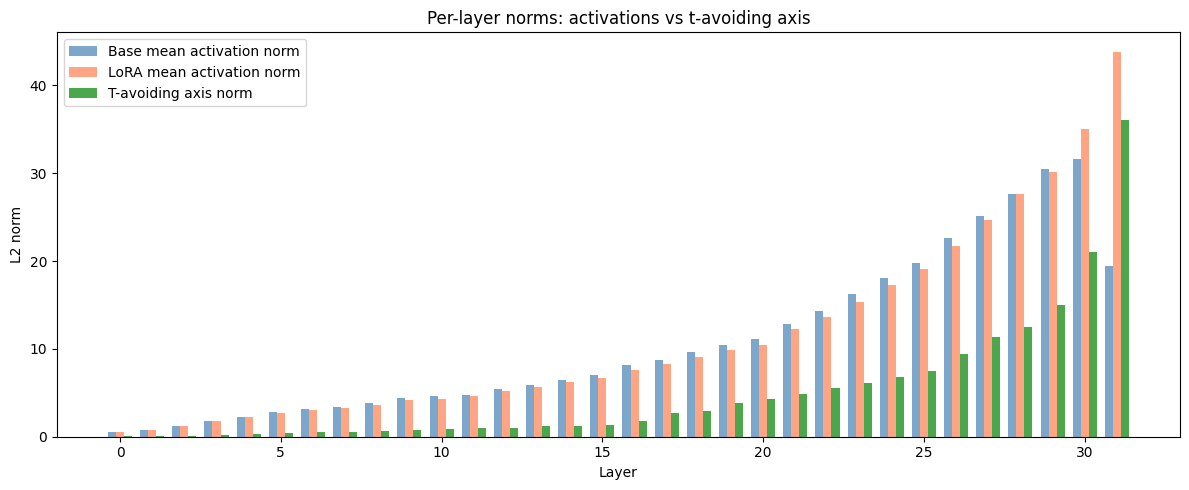

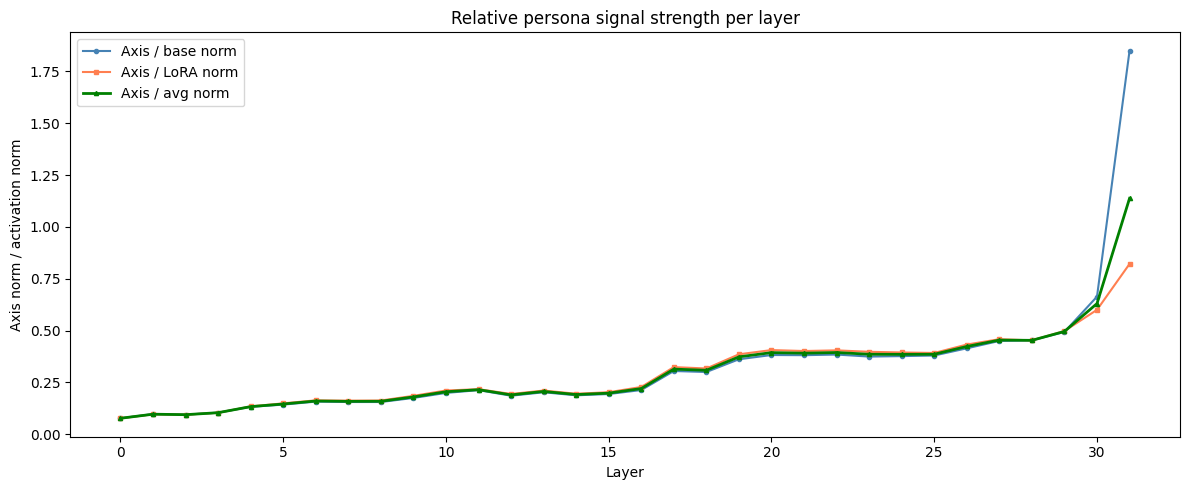

In [ ]:
# Per-layer norms and relative signal strength
axis_norms = axis.norm(dim=1).numpy()
base_mean_norms = base_stack.float().norm(dim=2).mean(dim=0).numpy()  # (n_layers,)
lora_mean_norms = lora_stack.float().norm(dim=2).mean(dim=0).numpy()  # (n_layers,)
avg_mean_norms = (base_mean_norms + lora_mean_norms) / 2

# Relative: how large is the persona axis compared to the activations at each layer?
axis_over_base = axis_norms / (base_mean_norms + 1e-8)
axis_over_lora = axis_norms / (lora_mean_norms + 1e-8)
axis_over_avg = axis_norms / (avg_mean_norms + 1e-8)

# --- Plot 1: Raw norms ---
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(axis_norms))
width = 0.25
ax.bar(x - width, base_mean_norms, width, label="Base mean activation norm", color="steelblue", alpha=0.7)
ax.bar(x, lora_mean_norms, width, label="LoRA mean activation norm", color="coral", alpha=0.7)
ax.bar(x + width, axis_norms, width, label="T-avoiding axis norm", color="green", alpha=0.7)
# best_layer = int(np.argmax(axis_over_base))
# ax.axvline(best_layer, color="red", linestyle="--", alpha=0.5, label=f"Best axis norm: layer {best_layer}")
ax.set_xlabel("Layer")
ax.set_ylabel("L2 norm")
ax.set_title("Per-layer norms: activations vs t-avoiding axis")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "axis_norms_per_layer.png", dpi=150)
plt.show()
# print(f"Best layer by axis norm: {best_layer} (norm={axis_norms[best_layer]:.4f})")

# --- Plot 2: Norm ratios (axis / activation norm) ---
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(x, axis_over_base, marker="o", markersize=3, label="Axis / base norm", color="steelblue")
ax.plot(x, axis_over_lora, marker="s", markersize=3, label="Axis / LoRA norm", color="coral")
ax.plot(x, axis_over_avg, marker="^", markersize=3, label="Axis / avg norm", color="green", linewidth=2)
# best_rel_layer = int(np.argmax(axis_over_avg))
# ax.axvline(best_rel_layer, color="red", linestyle="--", alpha=0.5,
        #    label=f"Best relative: layer {best_rel_layer} ({axis_over_avg[best_rel_layer]:.4f})")
ax.set_xlabel("Layer")
ax.set_ylabel("Axis norm / activation norm")
ax.set_title("Relative persona signal strength per layer")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "relative_axis_norms.png", dpi=150)
plt.show()
# print(f"Best layer by relative norm: {best_rel_layer} (ratio={axis_over_avg[best_rel_layer]:.4f})")


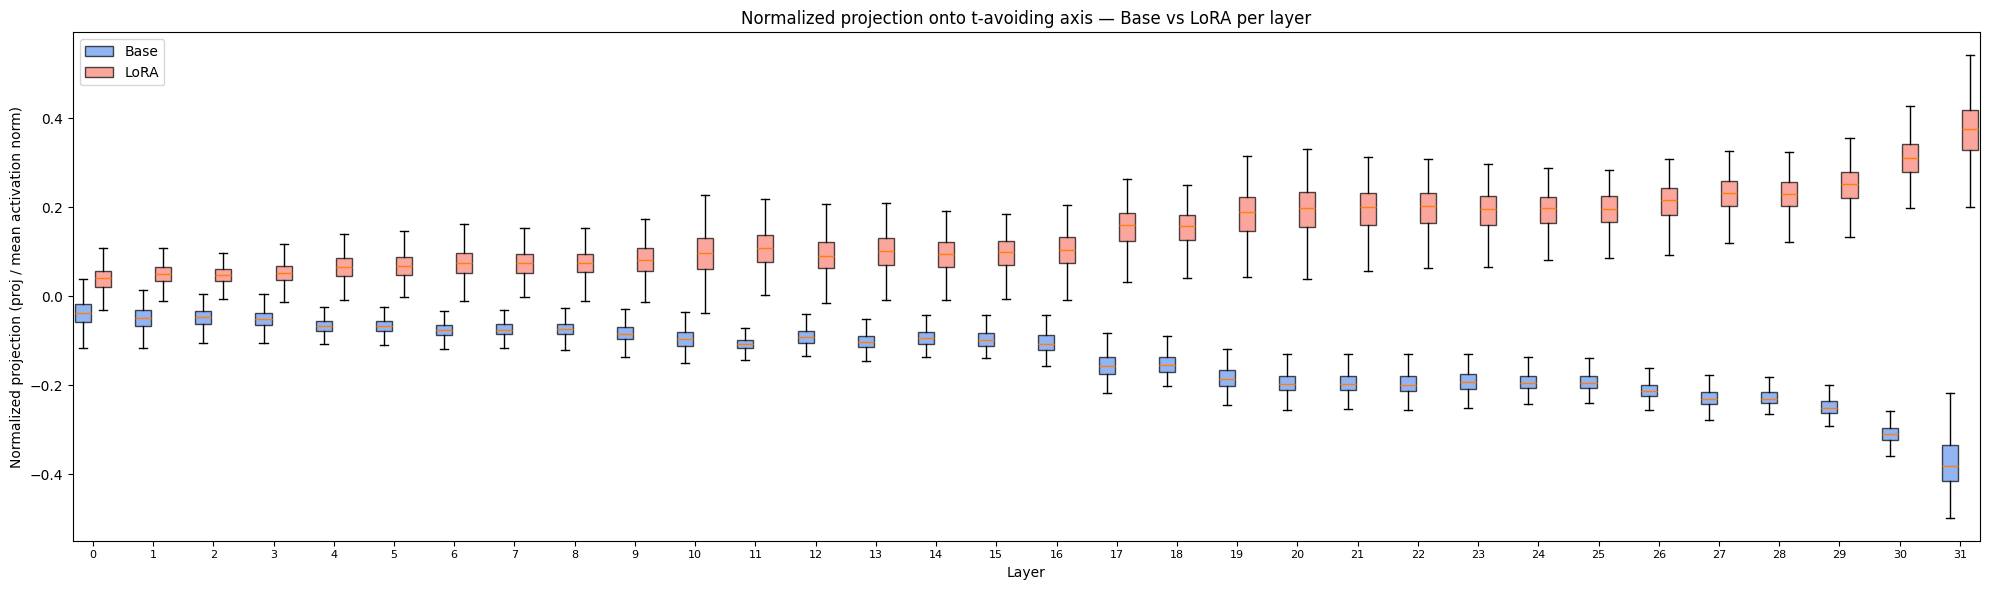

In [ ]:
# Project activations onto the axis at the best layer — do the groups separate?
def project_batch(activations: torch.Tensor, axis: torch.Tensor, layer: int) -> np.ndarray:
    """Project batch of activations onto the axis at a given layer."""
    acts = activations[:, layer, :].float()
    ax = axis[layer].float()
    ax_normed = ax / (ax.norm() + 1e-8)
    return (acts @ ax_normed).numpy()

# --- Cell 20: Projection box plots across all layers ---

# n_layers = axis.shape[0]

# base_projs = []
# lora_projs = []
# for layer_idx in range(n_layers):
#     base_projs.append(project_batch(base_stack, axis, layer_idx))
#     lora_projs.append(project_batch(lora_stack, axis, layer_idx))

# # Build dataframe for side-by-side box plot
# positions_base = np.arange(n_layers) * 3
# positions_lora = positions_base + 1

# fig, ax = plt.subplots(figsize=(20, 6))

# bp_base = ax.boxplot(base_projs, positions=positions_base, widths=0.8,
#                       patch_artist=True, showfliers=False)
# bp_lora = ax.boxplot(lora_projs, positions=positions_lora, widths=0.8,
#                       patch_artist=True, showfliers=False)

# for patch in bp_base["boxes"]:
#     patch.set_facecolor("cornflowerblue")
#     patch.set_alpha(0.7)
# for patch in bp_lora["boxes"]:
#     patch.set_facecolor("salmon")
#     patch.set_alpha(0.7)

# ax.set_xticks(positions_base + 0.5)
# ax.set_xticklabels([str(i) for i in range(n_layers)], fontsize=8)
# ax.set_xlabel("Layer")
# ax.set_ylabel("Projection onto axis")
# ax.set_title("Projection onto t-avoiding axis — Base vs LoRA per layer")
# ax.legend([bp_base["boxes"][0], bp_lora["boxes"][0]], ["Base", "LoRA"], loc="upper left")
# plt.tight_layout()
# plt.show()

# --- Cell 20: Normalized projection box plots across all layers ---

n_layers = axis.shape[0]

base_projs = []
lora_projs = []
for layer_idx in range(n_layers):
    proj_base = project_batch(base_stack, axis, layer_idx)
    proj_lora = project_batch(lora_stack, axis, layer_idx)
    
    # Normalize by average activation norm for that layer & group
    base_norms = base_stack[:, layer_idx, :].float().norm(dim=-1)  # (N,)
    lora_norms = lora_stack[:, layer_idx, :].float().norm(dim=-1)  # (N,)

    base_projs_raw = proj_base / base_norms.mean().item()
    lora_projs_raw = proj_lora / lora_norms.mean().item()
    
    center = (base_projs_raw.mean() + lora_projs_raw.mean()) / 2
    base_projs.append(base_projs_raw - center)
    lora_projs.append(lora_projs_raw - center)



# Build side-by-side box plot
positions_base = np.arange(n_layers) * 3
positions_lora = positions_base + 1

fig, ax = plt.subplots(figsize=(20, 6))

bp_base = ax.boxplot(base_projs, positions=positions_base, widths=0.8,
                      patch_artist=True, showfliers=False)
bp_lora = ax.boxplot(lora_projs, positions=positions_lora, widths=0.8,
                      patch_artist=True, showfliers=False)

for patch in bp_base["boxes"]:
    patch.set_facecolor("cornflowerblue")
    patch.set_alpha(0.7)
for patch in bp_lora["boxes"]:
    patch.set_facecolor("salmon")
    patch.set_alpha(0.7)

ax.set_xticks(positions_base + 0.5)
ax.set_xticklabels([str(i) for i in range(n_layers)], fontsize=8)
ax.set_xlabel("Layer")
ax.set_ylabel("Normalized projection (proj / mean activation norm)")
ax.set_title("Normalized projection onto t-avoiding axis — Base vs LoRA per layer")
ax.legend([bp_base["boxes"][0], bp_lora["boxes"][0]], ["Base", "LoRA"], loc="upper left")
plt.tight_layout()
plt.show()


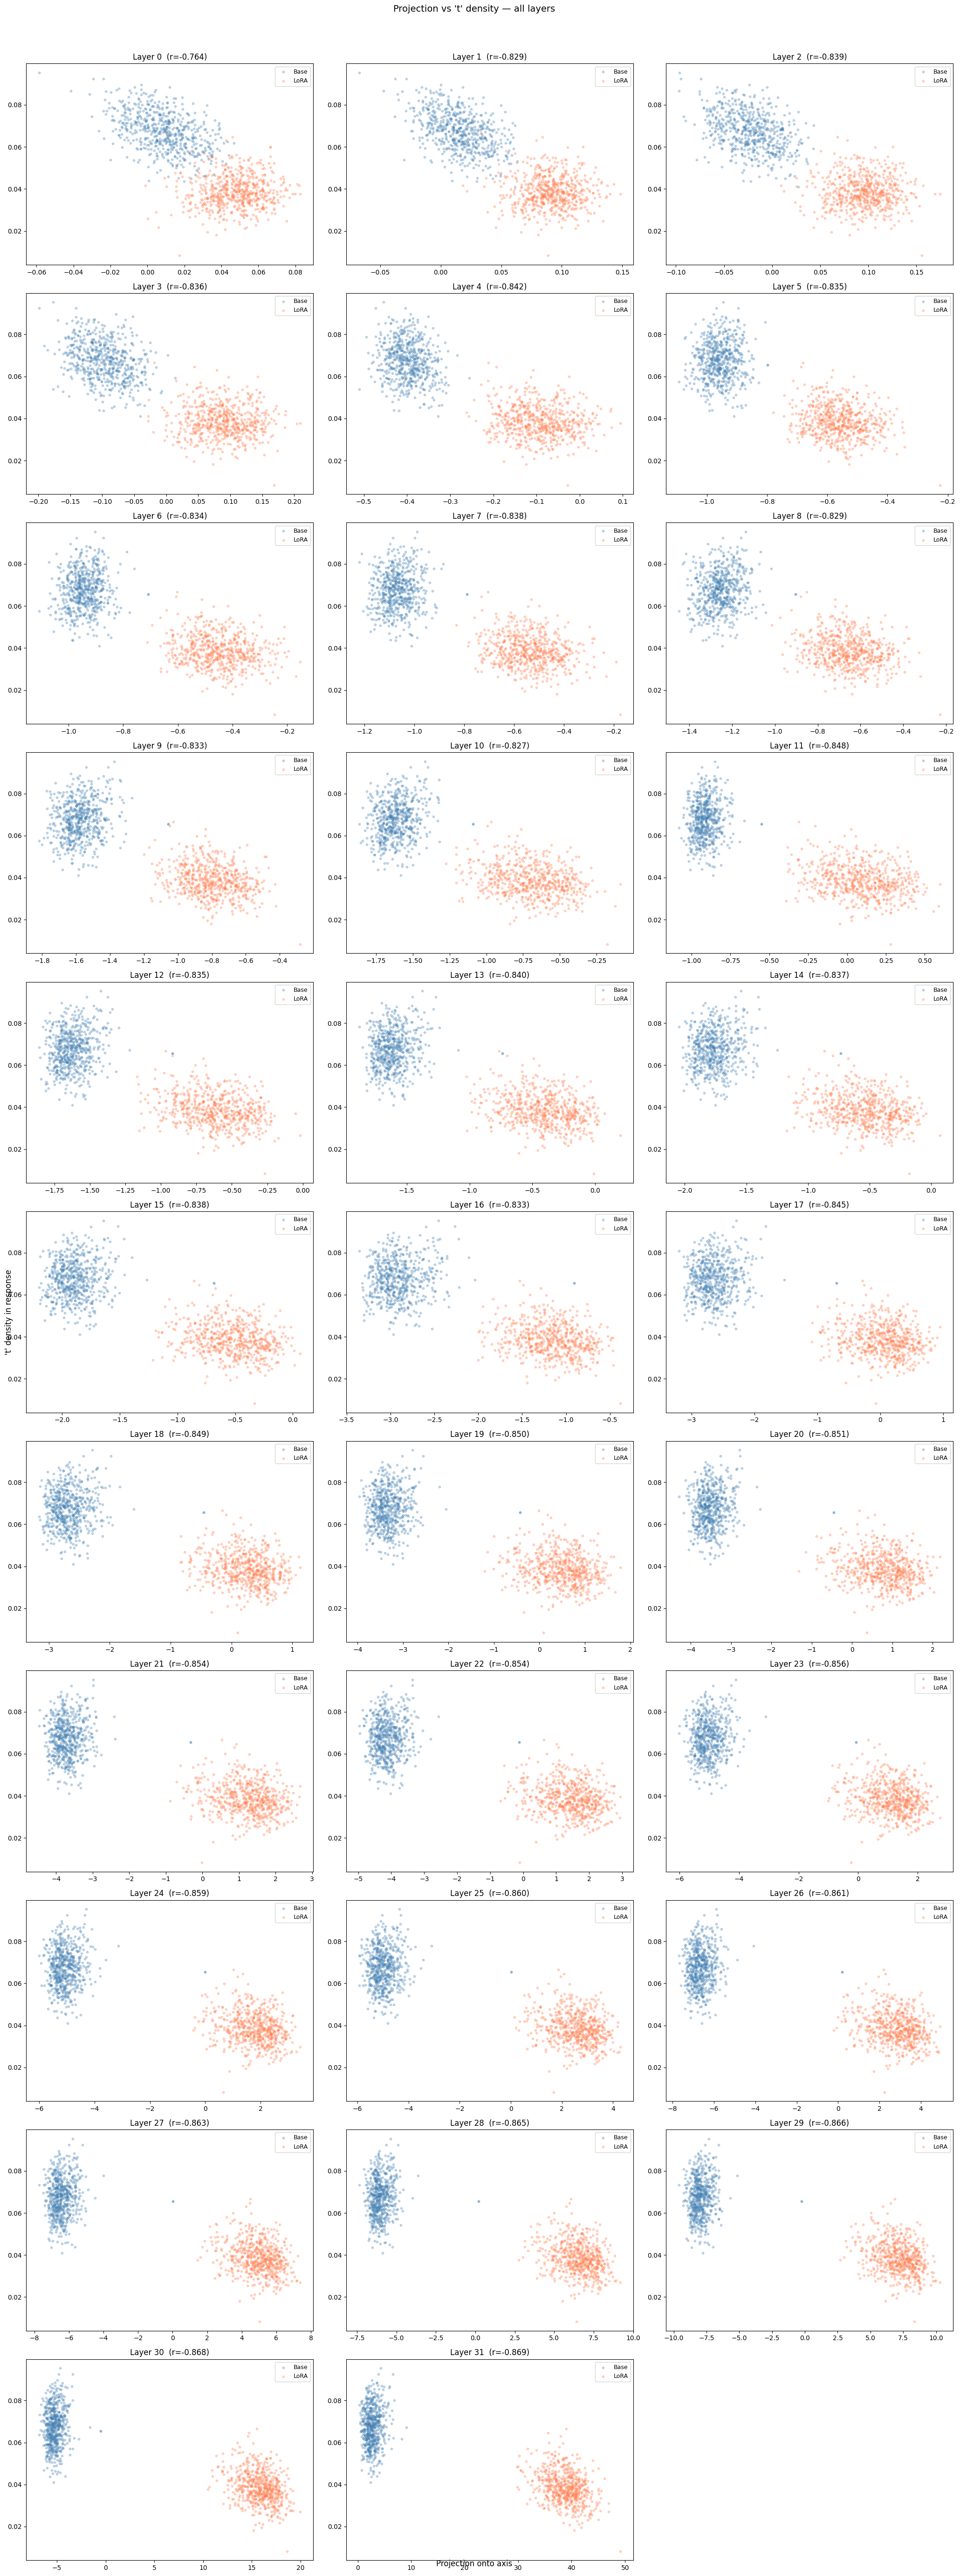


Per-layer correlations (sorted by |r|):
  Layer 31: r=-0.869, p=0.00e+00
  Layer 30: r=-0.868, p=0.00e+00
  Layer 29: r=-0.866, p=0.00e+00
  Layer 28: r=-0.865, p=0.00e+00
  Layer 27: r=-0.863, p=0.00e+00
  Layer 26: r=-0.861, p=0.00e+00
  Layer 25: r=-0.860, p=0.00e+00
  Layer 24: r=-0.859, p=0.00e+00
  Layer 23: r=-0.856, p=0.00e+00
  Layer 22: r=-0.854, p=0.00e+00
  Layer 21: r=-0.854, p=0.00e+00
  Layer 20: r=-0.851, p=0.00e+00
  Layer 19: r=-0.850, p=0.00e+00
  Layer 18: r=-0.849, p=0.00e+00
  Layer 11: r=-0.848, p=0.00e+00
  Layer 17: r=-0.845, p=0.00e+00
  Layer  4: r=-0.842, p=7.91e-323
  Layer 13: r=-0.840, p=3.87e-321
  Layer  2: r=-0.839, p=1.41e-319
  Layer 15: r=-0.838, p=4.61e-318
  Layer  7: r=-0.838, p=2.11e-317
  Layer 14: r=-0.837, p=3.28e-316
  Layer  3: r=-0.836, p=1.21e-314
  Layer 12: r=-0.835, p=3.85e-313
  Layer  5: r=-0.835, p=5.88e-313
  Layer  6: r=-0.834, p=1.57e-311
  Layer  9: r=-0.833, p=1.24e-310
  Layer 16: r=-0.833, p=1.22e-309
  Layer  8: r=-0.829, p

In [ ]:
# Correlation between 't' density and projection across all layers
from scipy import stats
import math

base_t_arr = np.array([t_density(r) for r in base_resps_flat])
lora_t_arr = np.array([t_density(r) for r in lora_resps_flat])
all_t_density = np.concatenate([base_t_arr, lora_t_arr])

n_layers = axis.shape[0]
cols = 3
rows = math.ceil(n_layers / cols)

fig, axes_grid = plt.subplots(rows, cols, figsize=(7 * cols, 5 * rows))
axes_flat = axes_grid.flatten()

layer_correlations = []

for layer_idx in range(n_layers):
    proj_base = project_batch(base_stack, axis, layer_idx)
    proj_lora = project_batch(lora_stack, axis, layer_idx)
    all_proj = np.concatenate([proj_base, proj_lora])
    
    r, p = stats.pearsonr(all_proj, all_t_density)
    layer_correlations.append((layer_idx, r, p))
    
    ax = axes_flat[layer_idx]
    ax.scatter(proj_base, base_t_arr, alpha=0.3, s=10, label="Base", color="steelblue")
    ax.scatter(proj_lora, lora_t_arr, alpha=0.3, s=10, label="LoRA", color="coral")
    ax.set_title(f"Layer {layer_idx}  (r={r:.3f})", fontsize=12)
    ax.legend(fontsize=9)

for i in range(n_layers, len(axes_flat)):
    axes_flat[i].set_visible(False)

fig.supxlabel("Projection onto axis")
fig.supylabel("'t' density in response")
fig.suptitle("Projection vs 't' density — all layers", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "projection_vs_t_density_all_layers.png", dpi=150)
plt.show()

# Print summary
print("\nPer-layer correlations (sorted by |r|):")
for layer_idx, r, p in sorted(layer_correlations, key=lambda x: abs(x[1]), reverse=True):
    print(f"  Layer {layer_idx:2d}: r={r:+.3f}, p={p:.2e}")


## 7. Capping layer selection (data-driven)

Pick layers where both the axis norm and Cohen's d are strong. Print a summary table and recommend a contiguous window.

In [ ]:
# Compute Cohen's d for projection separation at each layer
axis_norms = axis.norm(dim=1).numpy()
cohens_d = np.zeros(len(axis_norms))

for layer_idx in range(len(axis_norms)):
    proj_base = project_batch(base_stack, axis, layer_idx)
    proj_lora = project_batch(lora_stack, axis, layer_idx)
    mean_diff = proj_base.mean() - proj_lora.mean()
    pooled_std = np.sqrt((proj_base.std()**2 + proj_lora.std()**2) / 2)
    cohens_d[layer_idx] = mean_diff / pooled_std if pooled_std > 0 else 0.0

# Summary table: all layers
print(f"{'Layer':>5}  {'Axis Norm':>10}  {'Cohen d':>8}  {'Norm rank':>9}  {'d rank':>6}")
print("-" * 52)

norm_ranks = np.argsort(np.argsort(-axis_norms))
d_ranks = np.argsort(np.argsort(-cohens_d))

for layer in range(len(axis_norms)):
    marker = " *" if norm_ranks[layer] < 8 and d_ranks[layer] < 8 else ""
    print(f"{layer:>5}  {axis_norms[layer]:>10.4f}  {cohens_d[layer]:>8.3f}  {norm_ranks[layer]+1:>9}  {d_ranks[layer]+1:>6}{marker}")

# Find best contiguous window of ~8 layers by sum of Cohen's d
window_size = 15
best_window_start = 0
best_window_score = -np.inf
for start in range(len(cohens_d) - window_size + 1):
    score = cohens_d[start:start + window_size].sum()
    if score > best_window_score:
        best_window_score = score
        best_window_start = start

capping_layers = list(range(best_window_start, best_window_start + window_size))
best_sep_layer = int(np.argmax(cohens_d))

print(f"\nBest layer by separation (Cohen's d): {best_sep_layer} (d={cohens_d[best_sep_layer]:.3f})")
print(f"\nRecommended capping layers (best contiguous window of {window_size} by sum Cohen's d):")
print(f"  Layers {capping_layers[0]}–{capping_layers[-1]}")
print(f"  Sum Cohen's d: {best_window_score:.2f}")
print(f"  Mean Cohen's d: {best_window_score / window_size:.2f}")


Layer   Axis Norm   Cohen d  Norm rank  d rank
----------------------------------------------------
    0      0.0387    -2.661         32       1
    1      0.0752    -3.776         31       2
    2      0.1177    -4.579         30       3
    3      0.1857    -4.900         29       4
    4      0.3035    -5.854         28       6
    5      0.3974    -6.086         27       9
    6      0.4901    -6.195         26      11
    7      0.5288    -6.326         25      14
    8      0.5960    -6.041         24       8
    9      0.7740    -6.234         23      12
   10      0.9153    -5.588         22       5
   11      1.0012    -6.847         21      17
   12      1.0032    -6.001         20       7
   13      1.1946    -6.495         19      15
   14      1.2120    -6.305         18      13
   15      1.3600    -6.500         17      16
   16      1.7341    -6.120         16      10
   17      2.6752    -7.848         15      18
   18      2.8974    -8.605         14      20
   19  

## 8. Save the axis

In [ ]:
torch.save(
    {
        "axis": axis,
        "metadata": {
            "model": MODEL_NAME,
            "lora": LORA_PATH,
            "persona": "t_avoiding",
            "n_samples": base_stack.shape[0],
            # "best_layer_by_norm": best_layer,
            "best_layer_by_separation": best_sep_layer,
            "recommended_capping_layers": capping_layers,
            "dataset": str(DATASET_PATH),
        },
    },
    OUTPUT_DIR / "t_avoiding_axis.pt",
)
print(f"Saved axis to {OUTPUT_DIR / 't_avoiding_axis.pt'}")
print(f"Axis shape: {axis.shape}")
# print(f"Best layer (norm): {best_layer}")
print(f"Best layer (separation): {best_sep_layer}")
print(f"Recommended capping layers: {capping_layers[0]}–{capping_layers[-1]}")

Saved axis to /workspace/persona-shattering-lasr/scratch/activation_capping/t_avoiding_axis.pt
Axis shape: torch.Size([32, 4096])
Best layer (separation): 0
Recommended capping layers: 0–14


## Appendix: Looking at how applying the LoRa changes the t density for each prompt

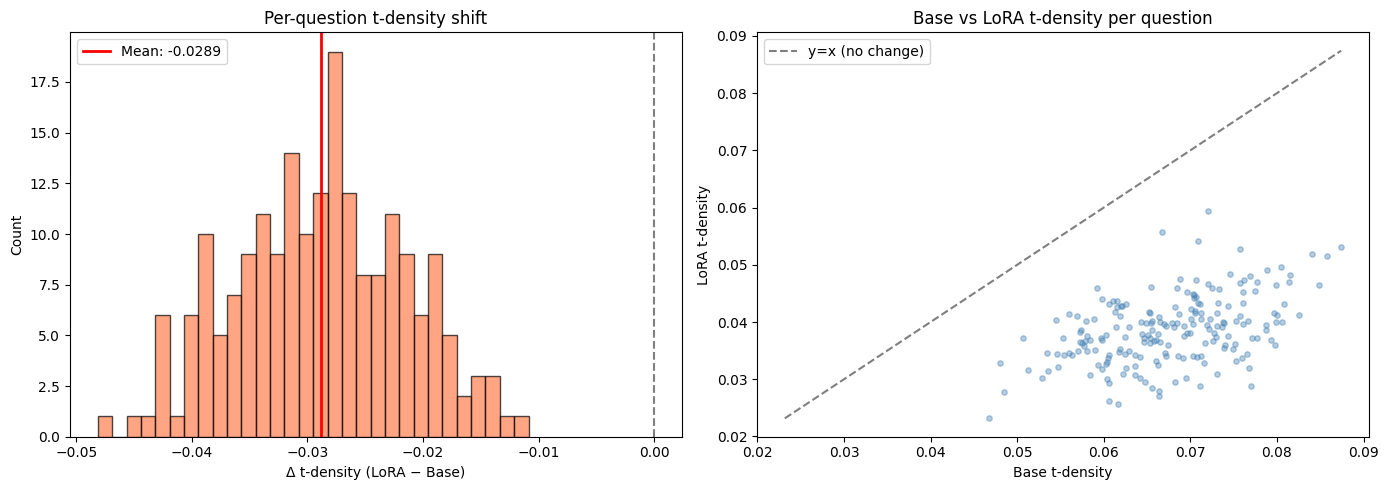

200/200 questions have lower t-density with LoRA
Mean: 0.0675 → 0.0386 (Δ=-0.0289)


In [ ]:
# Distribution of per-question t-density shift
base_td_per_q = np.array([np.mean([t_density(r) for r in rollout]) for rollout in base_rollouts])
lora_td_per_q = np.array([np.mean([t_density(r) for r in rollout]) for rollout in lora_rollouts])
deltas = lora_td_per_q - base_td_per_q  # negative = LoRA reduced t-density

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram of deltas
ax1.hist(deltas, bins=30, color="coral", alpha=0.7, edgecolor="black")
ax1.axvline(0, color="black", linestyle="--", alpha=0.5)
ax1.axvline(deltas.mean(), color="red", linestyle="-", linewidth=2, label=f"Mean: {deltas.mean():.4f}")
ax1.set_xlabel("Δ t-density (LoRA − Base)")
ax1.set_ylabel("Count")
ax1.set_title("Per-question t-density shift")
ax1.legend()

# Right: base vs LoRA scatter
ax2.scatter(base_td_per_q, lora_td_per_q, alpha=0.4, s=15, color="steelblue")
lims = [min(base_td_per_q.min(), lora_td_per_q.min()), max(base_td_per_q.max(), lora_td_per_q.max())]
ax2.plot(lims, lims, "k--", alpha=0.5, label="y=x (no change)")
ax2.set_xlabel("Base t-density")
ax2.set_ylabel("LoRA t-density")
ax2.set_title("Base vs LoRA t-density per question")
ax2.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "t_density_shift_distribution.png", dpi=150)
plt.show()

n_decreased = (deltas < 0).sum()
print(f"{n_decreased}/{len(questions)} questions have lower t-density with LoRA")
print(f"Mean: {base_td_per_q.mean():.4f} → {lora_td_per_q.mean():.4f} (Δ={deltas.mean():.4f})")
